### ADELINE MAKOKHA 
### 191199 
### PREDICTIVE OPTIMIZATION ANALYTICS
### CAT 1

### Vehicle Insurance Fraud Detection
Vehicle insurance fraud involves conspiring to file false or exaggerated claims related to property damage or personal injuries following an accident. Common examples include staged accidents, where fraudsters deliberately "orchestrate" collisions; the use of phantom passengers, where individuals do not present at the accident scene falsely claim to have suffered severe injuries; and exaggerated personal injury claims, where minor injuries are portrayed as serious to maximize
compensation.
You have been assigned the task of developing a predictive model optimized to identify potential fraudulent cases. [Click here to access the dataset you will be using.]

NB. Use F1_score to evaluate your performance across all models or Alternative Use Smote to sort the class imbalance then use Accuracy, which ever choice of your metrics
ensure consistency across the work.



In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import validation_curve, RandomizedSearchCV
import joblib
import warnings
warnings.filterwarnings("ignore")



## Load the Data

In [2]:
url = "https://raw.githubusercontent.com/NUELBUNDI/Machine-Learning-Data-Set/refs/heads/main/Insurance%20Fraud%20data.csv"
df = pd.read_csv(url)
df.shape

(15420, 33)

In [3]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [4]:
df["FraudFound_P"].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

The last output shows how many cases are fraud (`1`) versus non-fraud (`0`).  
A big gap means the model can get high accuracy by predicting the majority class, so I use **F1-score** to keep focus on detecting fraud without ignoring false alarms.

Follow the steps below
## Step 1: Data Preprocessing (7 Marks) (Choice which steps are more applicable to you)

Prepare your dataset for modeling by performing the following tasks. For each step you decide to use, provide comments and explanations for your choices and outputs:

### a. Data Cleaning

➢ Handle missing values, duplicates, or outliers.



In [5]:
# Missing values
df.isna().sum().sort_values(ascending=False).head(10)

Month                  0
RepNumber              0
Year                   0
NumberOfCars           0
AddressChange_Claim    0
NumberOfSuppliments    0
AgentType              0
WitnessPresent         0
PoliceReportFiled      0
AgeOfPolicyHolder      0
dtype: int64

In [6]:
# Duplicate rows
df.duplicated().sum()

0

In [7]:
# Quick check for suspicious age values
df["Age"].describe()

count    15420.000000
mean        39.855707
std         13.492377
min          0.000000
25%         31.000000
50%         38.000000
75%         48.000000
max         80.000000
Name: Age, dtype: float64

The dataset has no empty cells and no exact duplicate rows.  
However, `Age` includes zeros. A driving age of 0 is not realistic, so I treat `Age==0` as "unknown" and replace it using the median age.

In [8]:
df_clean = df.copy()

# Replace Age==0 with median (computed on non-zero ages)
age_median = df_clean.loc[df_clean["Age"] > 0, "Age"].median()
df_clean.loc[df_clean["Age"] == 0, "Age"] = age_median

df_clean["Age"].describe()

count    15420.000000
mean        40.665045
std         12.183501
min         16.000000
25%         31.000000
50%         39.000000
75%         48.000000
max         80.000000
Name: Age, dtype: float64


### b. Feature Engineering and Extraction

➢ Derive new features from existing ones to enhance predictive power.

In [9]:
# Helper functions for mapping
def mid_of_range(text):
    # Examples: "20000 to 29000", "less than 20000", "more than 69000"
    if isinstance(text, str):
        t = text.strip().lower()
        if "to" in t:
            a, b = t.split("to")
            a = float(a.strip())
            b = float(b.strip())
            return (a + b) / 2.0
        if "less than" in t:
            # pick a conservative midpoint below the threshold
            x = float(t.replace("less than", "").strip())
            return x * 0.75
        if "more than" in t:
            x = float(t.replace("more than", "").strip())
            return x * 1.15
    return np.nan

def years_to_num(text):
    # Examples: "new", "3 years", "more than 7"
    if isinstance(text, str):
        t = text.strip().lower()
        if t == "new":
            return 0.0
        if "more than" in t:
            return 8.0
        if "year" in t:
            return float(t.split()[0])
    return np.nan

def ageband_mid(text):
    # Examples: "26 to 30", "over 65"
    if isinstance(text, str):
        t = text.strip().lower()
        if "to" in t:
            a, b = t.split("to")
            a = float(a.strip())
            b = float(b.strip())
            return (a + b) / 2.0
        if "over" in t:
            x = float(t.replace("over", "").strip())
            return x + 5.0
    return np.nan

def claims_to_num(text):
    # Examples: "none", "1", "2 to 4", "more than 4"
    if isinstance(text, str):
        t = text.strip().lower()
        if t == "none":
            return 0.0
        if t.isdigit():
            return float(t)
        if "to" in t:
            a, b = t.split("to")
            a = float(a.strip())
            b = float(b.strip())
            return (a + b) / 2.0
        if "more than" in t:
            x = float(t.replace("more than", "").strip())
            return x + 1.0
    return np.nan

def addr_change_months(text):
    # Examples: "no change", "under 6 months", "1 year", "2 to 3 years", "4 to 8 years"
    if isinstance(text, str):
        t = text.strip().lower()
        if t == "no change":
            return 0.0
        if "under" in t and "months" in t:
            return 3.0
        if "year" in t and "to" not in t:
            # "1 year"
            n = float(t.split()[0])
            return n * 12.0
        if "to" in t and "year" in t:
            # "2 to 3 years"
            a, b = t.replace("years", "").replace("year", "").split("to")
            a = float(a.strip())
            b = float(b.strip())
            return ((a + b) / 2.0) * 12.0
    return np.nan

def cars_to_num(text):
    # Examples: "1 vehicle", "2 vehicles", "3 to 4", "5 to 8", "more than 8"
    if isinstance(text, str):
        t = text.strip().lower()
        if "vehicle" in t:
            return float(t.split()[0])
        if "to" in t:
            a, b = t.split("to")
            a = float(a.strip())
            b = float(b.strip())
            return (a + b) / 2.0
        if "more than" in t:
            x = float(t.replace("more than", "").strip())
            return x + 1.0
    return np.nan

def days_bucket_to_num(text):
    # Examples: "none", "1 to 7", "8 to 15", "15 to 30", "more than 30"
    if isinstance(text, str):
        t = text.strip().lower()
        if t == "none":
            return 0.0
        if "to" in t:
            a, b = t.split("to")
            a = float(a.strip())
            b = float(b.strip())
            return (a + b) / 2.0
        if "more than" in t:
            x = float(t.replace("more than", "").strip())
            return x + 15.0
    return np.nan

df_fe = df_clean.copy()

df_fe["VehiclePrice_num"] = df_fe["VehiclePrice"].apply(mid_of_range)
df_fe["VehicleAge_num"] = df_fe["AgeOfVehicle"].apply(years_to_num)
df_fe["PolicyHolderAge_num"] = df_fe["AgeOfPolicyHolder"].apply(ageband_mid)
df_fe["PastClaims_num"] = df_fe["PastNumberOfClaims"].apply(claims_to_num)
df_fe["AddrChange_months"] = df_fe["AddressChange_Claim"].apply(addr_change_months)
df_fe["Cars_num"] = df_fe["NumberOfCars"].apply(cars_to_num)
df_fe["DaysPolicyAcc_num"] = df_fe["Days_Policy_Accident"].apply(days_bucket_to_num)
df_fe["DaysPolicyClaim_num"] = df_fe["Days_Policy_Claim"].apply(days_bucket_to_num)

# Example: a simple "claim lag" proxy (bigger means the claim happens later)
df_fe["ClaimLag_proxy"] = df_fe["DaysPolicyClaim_num"] - df_fe["DaysPolicyAcc_num"]

df_fe[["VehiclePrice", "VehiclePrice_num", "AgeOfVehicle", "VehicleAge_num"]].head()

,VehiclePrice,VehiclePrice_num,AgeOfVehicle,VehicleAge_num
0,more than 69000,79350.0,3 years,3.0
1,more than 69000,79350.0,6 years,6.0
2,more than 69000,79350.0,7 years,7.0
3,20000 to 29000,24500.0,more than 7,8.0
4,more than 69000,79350.0,5 years,5.0


The new `_num` columns keep the ordering information from the original text ranges.  
This helps models pick up patterns like "higher car price" or "longer delay before claim" without needing dozens of one-hot columns.

### c. Feature Selection
➢ Select the most relevant features using techniques such as correlation analysis, Recursive Feature Elimination (RFE), or tree-based feature importance.


In [10]:
drop_cols = ["PolicyNumber", "RepNumber"]

# also drop the original ordinal-text columns after creating numeric versions
drop_cols += [
    "VehiclePrice", "AgeOfVehicle", "AgeOfPolicyHolder",
    "PastNumberOfClaims", "AddressChange_Claim", "NumberOfCars",
    "Days_Policy_Accident", "Days_Policy_Claim"
]

df_model = df_fe.drop(columns=drop_cols)

target = "FraudFound_P"
X = df_model.drop(columns=[target])
y = df_model[target]

X.shape, y.shape

((15420, 31), (15420,))

 Remove pure identifiers that do not describe behaviour (e.g., `PolicyNumber`, `RepNumber`) to reduce noise and leakage risk.

### d. Feature Encoding

➢Convert categorical variables into numerical representations using one-hot encoding, label encoding, or ordinal encoding, depending on the variable type.



In [11]:
# Identify column types
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

cat_cols, len(cat_cols), len(num_cols)

(['Month',
  'DayOfWeek',
  'Make',
  'AccidentArea',
  'DayOfWeekClaimed',
  'MonthClaimed',
  'Sex',
  'MaritalStatus',
  'Fault',
  'PolicyType',
  'VehicleCategory',
  'PoliceReportFiled',
  'WitnessPresent',
  'AgentType',
  'NumberOfSuppliments',
  'BasePolicy'],
 16,
 15)

One-hot encoding for categoricals, and standard scaling for numeric features (important for ANN/MLP).

### e. Feature Scaling

➢ Standardize or normalize features to bring them to a similar scale, especially for models sensitive to feature magnitude (e.g., ANN).

In [12]:
# Train-test split with stratification to preserve the fraud rate in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Preprocessing: encode categoricals + scale numeric
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop"
)

X_train.shape, X_test.shape

((12336, 31), (3084, 31))

Stratified splitting keeps the fraud ratio similar in train and test sets.  
The preprocessing is fitted on the training set only, then applied to test data to avoid peeking.

## Step 2: Train a Decision Tree Classifier(3Mrk)
➢ Train a Decision Tree Classifier on the preprocessed data.


In [13]:
dt_base = DecisionTreeClassifier(random_state=42)

dt_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", dt_base)
])

dt_pipe.fit(X_train, y_train)

pred_train = dt_pipe.predict(X_train)
pred_test = dt_pipe.predict(X_test)

f1_train = f1_score(y_train, pred_train)
f1_test = f1_score(y_test, pred_test)

f1_train, f1_test

(1.0, 0.18508997429305912)

Fit the model in a pipeline, then compare train vs test performance to spot overfitting.

### ➢ Evaluate its performance using metrics like the F1 score or accuracy (if using SMOTE).

### ➢ Check for overfitting by comparing training and validation performance.



In [14]:
print("Decision Tree (baseline) — Test report")
print(classification_report(y_test, pred_test, digits=4))

Decision Tree (baseline) — Test report
              precision    recall  f1-score   support

           0     0.9483    0.9420    0.9451      2899
           1     0.1765    0.1946    0.1851       185

    accuracy                         0.8972      3084
   macro avg     0.5624    0.5683    0.5651      3084
weighted avg     0.9020    0.8972    0.8996      3084



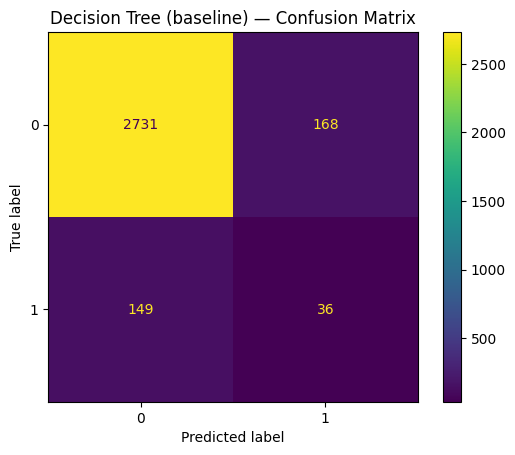

In [15]:
cm = confusion_matrix(y_test, pred_test, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot()
plt.title("Decision Tree (baseline) — Confusion Matrix")
plt.show()

If train F1 is much higher than test F1, the tree is fitting the training data too tightly.  
The confusion matrix shows how often fraud is caught (true positives) and how often clean cases are flagged (false positives).

## Step 3: Optimize Decision Tree Hyperparameters(4Mrk)

➢ Use a validation curve to identify the optimal values for max_depth and min_samples_leaf.


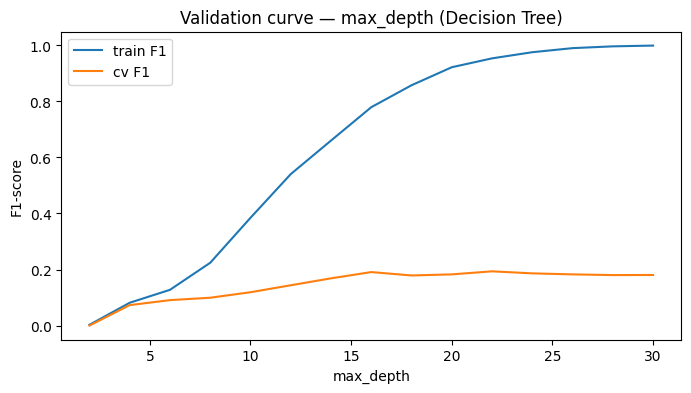

22

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

max_depth_range = np.arange(2, 31, 2)

train_scores, valid_scores = validation_curve(
    dt_pipe,
    X_train, y_train,
    param_name="model__max_depth",
    param_range=max_depth_range,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(8,4))
plt.plot(max_depth_range, train_mean, label="train F1")
plt.plot(max_depth_range, valid_mean, label="cv F1")
plt.xlabel("max_depth")
plt.ylabel("F1-score")
plt.title("Validation curve — max_depth (Decision Tree)")
plt.legend()
plt.show()

best_depth = max_depth_range[np.argmax(valid_mean)]
best_depth

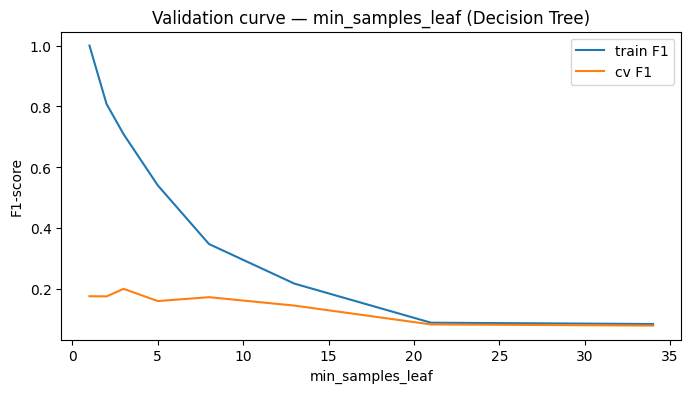

3

In [17]:
min_leaf_range = np.array([1,2,3,5,8,13,21,34])

train_scores2, valid_scores2 = validation_curve(
    dt_pipe,
    X_train, y_train,
    param_name="model__min_samples_leaf",
    param_range=min_leaf_range,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

train_mean2 = train_scores2.mean(axis=1)
valid_mean2 = valid_scores2.mean(axis=1)

plt.figure(figsize=(8,4))
plt.plot(min_leaf_range, train_mean2, label="train F1")
plt.plot(min_leaf_range, valid_mean2, label="cv F1")
plt.xlabel("min_samples_leaf")
plt.ylabel("F1-score")
plt.title("Validation curve — min_samples_leaf (Decision Tree)")
plt.legend()
plt.show()

best_leaf = min_leaf_range[np.argmax(valid_mean2)]
best_leaf

Sweep a range of values, use cross-validated F1, then retrain using the best pair.

### ➢ Retrain the Decision Tree using the optimal parameters.


In [18]:
# Retrain Decision Tree with the chosen values
dt_opt = DecisionTreeClassifier(
    random_state=42,
    max_depth=int(best_depth),
    min_samples_leaf=int(best_leaf)
)

dt_opt_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", dt_opt)
])

dt_opt_pipe.fit(X_train, y_train)

pred_train_opt = dt_opt_pipe.predict(X_train)
pred_test_opt = dt_opt_pipe.predict(X_test)

f1_train_opt = f1_score(y_train, pred_train_opt)
f1_test_opt = f1_score(y_test, pred_test_opt)

print("Baseline DT:  train F1 =", round(f1_train, 4), " test F1 =", round(f1_test, 4))
print("Tuned DT:     train F1 =", round(f1_train_opt, 4), " test F1 =", round(f1_test_opt, 4))

Baseline DT:  train F1 = 1.0  test F1 = 0.1851
Tuned DT:     train F1 = 0.7219  test F1 = 0.1581


### ➢ Compare the updated model’s performance to the initial model.


  
- `max_depth` controls how deep the tree can grow. Very deep trees usually overfit.  
- `min_samples_leaf` forces each leaf to have enough samples, smoothing noisy splits.  



### ➢ Comment on whether the optimization improved performance


An improvement is shown when **test F1 increases** without a huge gap between train and test.

## Step 4: Train Ensemble Models(7Mrk)

➢ Use at least two ensemble techniques we have learnt in class


In [19]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1,
        class_weight="balanced_subsample"
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)

    tr_pred = pipe.predict(X_train)
    te_pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "Train_F1": f1_score(y_train, tr_pred),
        "Test_F1": f1_score(y_test, te_pred)
    })

pd.DataFrame(results).sort_values("Test_F1", ascending=False)

,Model,Train_F1,Test_F1
1,GradientBoosting,0.097686,0.052083
0,RandomForest,1.000000,0.021390
2,AdaBoost,0.007947,0.010526


 I train three ensembles (Random Forest, Gradient Boosting, AdaBoost) using the same preprocessing and F1 metric.

### ➢ Evaluate the performance of each ensemble model and compare it to the Decision Tree model.


 
Ensembles usually beat a single tree because they combine many weak/medium learners:
- Random Forest averages many trees (lower variance).
- Boosting methods learn in stages to correct earlier mistakes (often higher recall on rare classes).



➢ Check for overfitting by analyzing performance on training and validation/test datasets.

Overfitting shows up when Train_F1 is high but Test_F1 drops.

➢ Provide an explanation for the observed performance.


## Step 5: Train an Artificial Neural Network (ANN)(5Mrk)
➢ Develop an ANN model with an architecture of your choice.

➢ Experiment with the number of layers, neurons, activation functions, and optimizers to improve performance.

➢ Retrain the ANN model and compare its results with previous model



In [20]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=80,
    random_state=42
)

mlp_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", mlp)
])

mlp_pipe.fit(X_train, y_train)

mlp_tr = mlp_pipe.predict(X_train)
mlp_te = mlp_pipe.predict(X_test)

print("MLP (ANN) — Train F1:", round(f1_score(y_train, mlp_tr), 4))
print("MLP (ANN) — Test  F1:", round(f1_score(y_test, mlp_te), 4))
print()
print(classification_report(y_test, mlp_te, digits=4))

MLP (ANN) — Train F1: 0.9993
MLP (ANN) — Test  F1: 0.1646

              precision    recall  f1-score   support

           0     0.9463    0.9600    0.9531      2899
           1     0.1888    0.1459    0.1646       185

    accuracy                         0.9112      3084
   macro avg     0.5675    0.5530    0.5589      3084
weighted avg     0.9008    0.9112    0.9058      3084



Use an `MLPClassifier` (feed-forward neural network). It needs scaling, so the same preprocessing is reused.

The MLP can capture interactions that are not obvious to trees, but it can also struggle with noisy categorical data.  
The real check is whether test F1 improves compared to the best tree/ensemble model.

## Step 6: Tune the Best-Performing Model (3Mrk)

➢ Select the best-performing model from the previous steps.


In [21]:
# Helper to fit and score quickly
def fit_score(pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    pred_te = pipe.predict(X_te)
    return f1_score(y_te, pred_te)

# Candidate pipelines (include tuned DT + ensembles + ANN)
candidates = {
    "DecisionTree_Tuned": dt_opt_pipe,
    "RandomForest": Pipeline([("prep", preprocess), ("model", models["RandomForest"])]),
    "GradientBoosting": Pipeline([("prep", preprocess), ("model", models["GradientBoosting"])]),
    "AdaBoost": Pipeline([("prep", preprocess), ("model", models["AdaBoost"])]),
    "MLP": mlp_pipe
}

scores = {name: fit_score(pipe, X_train, y_train, X_test, y_test) for name, pipe in candidates.items()}
scores

{'DecisionTree_Tuned': 0.1580547112462006,
 'RandomForest': 0.0213903743315508,
 'GradientBoosting': 0.052083333333333336,
 'AdaBoost': 0.010526315789473684,
 'MLP': 0.16463414634146342}

The next cell automatically selects the current best model based on test F1, then tunes it on the training set using cross-validation.

In [22]:
best_name = max(scores, key=scores.get)
best_name, scores[best_name]

('MLP', 0.16463414634146342)

### ➢ Use RandomizedSearchCV to fine-tune its hyperparameters.


In [23]:
best_pipe = candidates[best_name]

# Parameter search space depends on which model won
if best_name == "RandomForest":
    param_dist = {
        "model__n_estimators": [200, 400, 600, 800],
        "model__max_depth": [None, 6, 10, 14, 18],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", None],
    }
elif best_name == "GradientBoosting":
    param_dist = {
        "model__n_estimators": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [2, 3, 4, 5],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__min_samples_leaf": [1, 2, 4, 8],
    }
elif best_name == "AdaBoost":
    param_dist = {
        "model__n_estimators": [100, 200, 400, 600],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2, 0.5, 1.0],
    }
elif best_name == "DecisionTree_Tuned":
    param_dist = {
        "model__max_depth": list(range(2, 31, 2)),
        "model__min_samples_leaf": [1,2,3,5,8,13,21],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__criterion": ["gini", "entropy", "log_loss"],
    }
else:  # MLP
    param_dist = {
        "model__hidden_layer_sizes": [(64,32), (128,64), (128,64,32), (256,128)],
        "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
        "model__learning_rate_init": [1e-4, 5e-4, 1e-3, 2e-3],
    }

search = RandomizedSearchCV(
    estimator=best_pipe,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

search.fit(X_train, y_train)

search.best_params_, search.best_score_

({'model__learning_rate_init': 0.001,
  'model__hidden_layer_sizes': (128, 64, 32),
  'model__alpha': 0.01},
 0.18922942176400676)

In [24]:
best_tuned = search.best_estimator_

tuned_pred = best_tuned.predict(X_test)
tuned_f1 = f1_score(y_test, tuned_pred)

print("Best model before tuning:", best_name, "Test F1 =", round(scores[best_name], 4))
print("Best model after tuning: ", type(best_tuned.named_steps['model']).__name__, "Test F1 =", round(tuned_f1, 4))
print()
print(classification_report(y_test, tuned_pred, digits=4))

Best model before tuning: MLP Test F1 = 0.1646
Best model after tuning:  MLPClassifier Test F1 = 0.1796

              precision    recall  f1-score   support

           0     0.9470    0.9624    0.9547      2899
           1     0.2101    0.1568    0.1796       185

    accuracy                         0.9141      3084
   macro avg     0.5786    0.5596    0.5671      3084
weighted avg     0.9028    0.9141    0.9082      3084



➢ Evaluate whether the tuning improves the model’s performance and provide comments.


RandomizedSearchCV tries many reasonable parameter combinations quickly.  

➢ State you best model and its score either – F1 Score or Accuracy (If used SMOTE)

The tuning is useful only if the **test F1** improves or stays stable while the model becomes more general (smaller train–test gap).

## Step 7: Save Your Best Model (1 Mrk)

➢ Save the best-performing model to your local machine for future use.

➢ This model will be deployed later during the deployment class.



In [27]:
MODEL_PATH = r"C:\Users\PC\Downloads\ADEH-MSC\Module 5\Module-5\Predictive and Optimization Analytics\best_vehicle_fraud_model.joblib"
joblib.dump(best_tuned, MODEL_PATH)

MODEL_PATH


'C:\\Users\\PC\\Downloads\\ADEH-MSC\\Module 5\\Module-5\\Predictive and Optimization Analytics\\best_vehicle_fraud_model.joblib'

Save the full pipeline (preprocessing + model) using `joblib`.